# Data Visualization Recorded Data

## Imports

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Loading

In [58]:
df = pd.read_csv("data/300Hz_input_16_ch_2kHz_sampling_1kHz_fH_04.csv", sep=None, engine="python")

## Initial Data Inspection

In [59]:
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Detected separator — inferred from above")
df.head()

Shape: (43155, 17)
Columns: ['sample_num', 'ch0', 'ch1', 'ch2', 'ch3', 'ch4', 'ch5', 'ch6', 'ch7', 'ch8', 'ch9', 'ch10', 'ch11', 'ch12', 'ch13', 'ch14', 'ch15']
Detected separator — inferred from above


,sample_num,ch0,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8,ch9,ch10,ch11,ch12,ch13,ch14,ch15
0,0,3.0,-6389.0,-3764.0,-6389.0,-3506.0,-6311.0,-3032.0,284.0,-3395.0,-3815.0,-4271.0,-4132.0,-4043.0,-6054.0,-3213.0,-6389.0
1,1,3.0,-6389.0,-3673.0,-6389.0,-3422.0,-6314.0,-3045.0,203.0,-3430.0,-3827.0,-4252.0,-4091.0,-4023.0,-6160.0,-3260.0,-6389.0
2,2,4.0,-6389.0,-3690.0,-6389.0,-3410.0,-6389.0,-2961.0,-393.0,-3288.0,-3670.0,-4061.0,-3934.0,-3894.0,-6112.0,-3123.0,-6389.0
3,3,0.0,-6389.0,-3592.0,-6389.0,-3324.0,-6382.0,-2873.0,-1233.0,-3206.0,-3604.0,-4045.0,-3960.0,-3889.0,-6092.0,-3071.0,-5086.0
4,4,0.0,-6389.0,-3290.0,-6389.0,-2943.0,-5975.0,-2664.0,-1746.0,-2959.0,-3376.0,-3747.0,-3635.0,-3605.0,-5936.0,-2809.0,-2077.0


In [60]:
FS = 2000  # Hz, sampling rate

n_samples = len(df)
duration_ms = n_samples / FS * 1000

print(f"Samples:  {n_samples}")
print(f"Duration: {duration_ms:.1f} ms")

max_duration_ms = duration_ms  # used as upper bound in plotting cell

Samples:  43155
Duration: 21577.5 ms


## Plotting - 16 channels à 2 kHz

In [61]:
# ── Signal parameters ──────────────────────────────────────────────
FS          = 2000
F_INPUT     = 300    # Hz, input signal frequency
CHANNEL     = "ch7"  # which channel to plot

# ── Window ─────────────────────────────────────────────────────────
START_MS    = 15000      # ms, start of the plot window

N_CYCLES    = 10      # number of oscillations to show (takes priority if not None)
WINDOW_MS   = None   # ms, time window to show (used if N_CYCLES is None)

# ── Axis limits ────────────────────────────────────────────────────
Y_MIN       = None   # µV, set to None for auto
Y_MAX       = None   # µV, set to None for auto

# ── Figure style ───────────────────────────────────────────────────
FIG_WIDTH   = 8      # inches
FIG_HEIGHT  = 3      # inches
LINE_WIDTH  = 1.2    # pt
LINE_COLOR  = "black"

FONT_SIZE_LABEL  = 12  # axis label font size
FONT_SIZE_TICK   = 10  # tick label font size
FONT_SIZE_TITLE  = 13  # title font size

SHOW_GRID   = True
SHOW_TITLE  = None

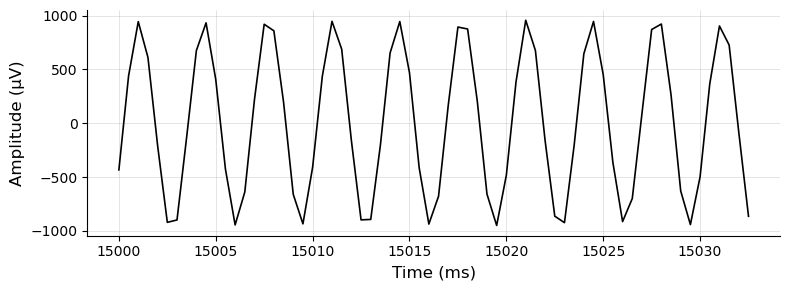

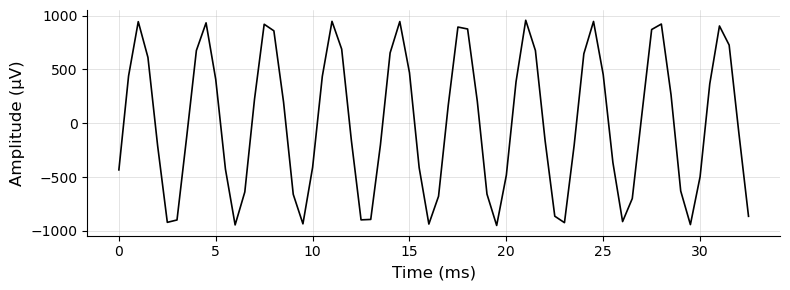

In [62]:
# ── Derived quantities ─────────────────────────────────────────────
if N_CYCLES is not None:
    window_ms = N_CYCLES / F_INPUT * 1000
else:
    window_ms = WINDOW_MS

end_ms = START_MS + window_ms
assert end_ms <= max_duration_ms, (
    f"Window end ({end_ms:.1f} ms) exceeds recording length ({max_duration_ms:.1f} ms)"
)

# ── Slice data ─────────────────────────────────────────────────────
start_idx = int(START_MS / 1000 * FS)
end_idx   = int(end_ms   / 1000 * FS)

time_ms = np.arange(start_idx, end_idx) / FS * 1000  # ms
signal  = df[CHANNEL].iloc[start_idx:end_idx].values  # µV

# ── Plot ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

ax.plot(time_ms, signal, linewidth=LINE_WIDTH, color=LINE_COLOR)

ax.set_xlabel("Time (ms)", fontsize=FONT_SIZE_LABEL)
ax.set_ylabel("Amplitude (µV)", fontsize=FONT_SIZE_LABEL)
ax.tick_params(labelsize=FONT_SIZE_TICK)

if Y_MIN is not None or Y_MAX is not None:
    ax.set_ylim(Y_MIN, Y_MAX)

if SHOW_TITLE:
    title = (f"{CHANNEL} — {F_INPUT} Hz input, "
             f"f_s = {FS} Hz, "
             f"{N_CYCLES} cycles" if N_CYCLES else f"{window_ms:.1f} ms window")
    ax.set_title(title, fontsize=FONT_SIZE_TITLE)

if SHOW_GRID:
    ax.grid(True, linewidth=0.4, alpha=0.6)

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# ── Same plot with x-axis starting at 0 ───────────────────────────
time_ms_zeroed = time_ms - time_ms[0]

fig2, ax2 = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

ax2.plot(time_ms_zeroed, signal, linewidth=LINE_WIDTH, color=LINE_COLOR)

ax2.set_xlabel("Time (ms)", fontsize=FONT_SIZE_LABEL)
ax2.set_ylabel("Amplitude (µV)", fontsize=FONT_SIZE_LABEL)
ax2.tick_params(labelsize=FONT_SIZE_TICK)

if Y_MIN is not None or Y_MAX is not None:
    ax2.set_ylim(Y_MIN, Y_MAX)

if SHOW_TITLE:
    ax2.set_title(title, fontsize=FONT_SIZE_TITLE)

if SHOW_GRID:
    ax2.grid(True, linewidth=0.4, alpha=0.6)

ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [63]:
# ── Sine fit style ─────────────────────────────────────────────────
SINE_COLOR      = "#E84A2F"   # color of the reference sine
SINE_LINE_STYLE = "--"        # linestyle for reference sine
SINE_LINE_WIDTH = 1.2         # pt
SINE_AMPLITUDE  = 1000        # µV, known input amplitude

SIGNAL_COLOR_OVERLAY = "black"
SIGNAL_LINE_WIDTH_OVERLAY = 1.2

LEGEND_FONT_SIZE = 10
LEGEND_LOCATION  = "upper right"  # "upper right", "lower right", etc.

SINE_OVERSAMPLE = 100  # factor above FS for the reference sine (higher = smoother curve)

# inherits FIG_WIDTH, FIG_HEIGHT, FONT_SIZE_LABEL, FONT_SIZE_TICK,
# FONT_SIZE_TITLE, SHOW_GRID, Y_MIN, Y_MAX from Cell 5

Target FFT bin: 10  (303.03 Hz)
Phase offset:   -28.26°


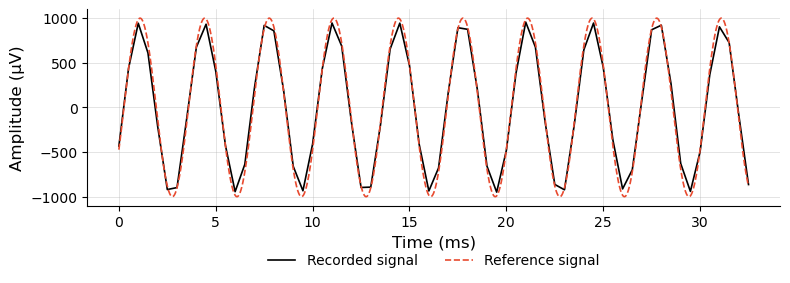

In [64]:
LEGEND_NCOL = 2   # number of columns in the legend

# ── Build reference sine on signal grid ───────────────────────────
n_samples_window = len(signal)
t_local = np.arange(n_samples_window) / FS
t_hires = np.linspace(0, t_local[-1],
                      n_samples_window * SINE_OVERSAMPLE)

ref_sine = np.sin(2 * np.pi * F_INPUT * t_local)

# ── FFT-based phase estimation (exact, no sample quantization) ─────
freq_resolution = FS / n_samples_window
target_bin      = round(F_INPUT / freq_resolution)

S = np.fft.rfft(signal - signal.mean())
R = np.fft.rfft(ref_sine)

phase_offset = np.angle(S[target_bin]) - np.angle(R[target_bin])

# ── Build fitted sine on high-res grid ────────────────────────────
fitted_sine = SINE_AMPLITUDE * np.sin(2 * np.pi * F_INPUT * t_hires + phase_offset)

print(f"Target FFT bin: {target_bin}  ({target_bin * freq_resolution:.2f} Hz)")
print(f"Phase offset:   {np.degrees(phase_offset):.2f}°")

# ── Plot ───────────────────────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

ax3.plot(time_ms_zeroed, signal,
         color=SIGNAL_COLOR_OVERLAY,
         linewidth=SIGNAL_LINE_WIDTH_OVERLAY,
         label="Recorded signal")

ax3.plot(t_hires * 1000, fitted_sine,
         color=SINE_COLOR,
         linewidth=SINE_LINE_WIDTH,
         linestyle=SINE_LINE_STYLE,
         label="Reference signal")

ax3.set_xlabel("Time (ms)", fontsize=FONT_SIZE_LABEL)
ax3.set_ylabel("Amplitude (µV)", fontsize=FONT_SIZE_LABEL)
ax3.tick_params(labelsize=FONT_SIZE_TICK)

if Y_MIN is not None or Y_MAX is not None:
    ax3.set_ylim(Y_MIN, Y_MAX)

if SHOW_TITLE:
    ax3.set_title(f"{CHANNEL} vs. reference signal — phase offset {np.degrees(phase_offset):.1f}°",
                  fontsize=FONT_SIZE_TITLE)

ax3.legend(fontsize=LEGEND_FONT_SIZE,
           loc="upper center",
           bbox_to_anchor=(0.5, -0.18),
           ncol=LEGEND_NCOL,
           frameon=False)

if SHOW_GRID:
    ax3.grid(True, linewidth=0.4, alpha=0.6)

ax3.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

Target FFT bin: 10  (303.03 Hz)
Phase offset:   -28.26°


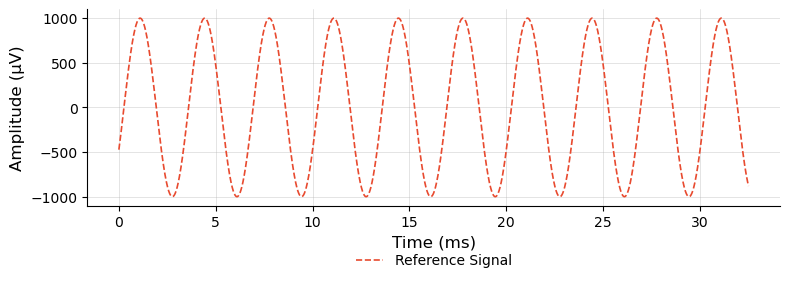

In [65]:
LEGEND_NCOL = 1   # optional: only one legend entry now

# ── Build reference sine on signal grid ───────────────────────────
n_samples_window = len(signal)
t_local = np.arange(n_samples_window) / FS
t_hires = np.linspace(0, t_local[-1],
                      n_samples_window * SINE_OVERSAMPLE)

ref_sine = np.sin(2 * np.pi * F_INPUT * t_local)

# ── FFT-based phase estimation (exact, no sample quantization) ─────
freq_resolution = FS / n_samples_window
target_bin      = round(F_INPUT / freq_resolution)

S = np.fft.rfft(signal - signal.mean())
R = np.fft.rfft(ref_sine)

phase_offset = np.angle(S[target_bin]) - np.angle(R[target_bin])

# ── Build fitted sine on high-res grid ────────────────────────────
fitted_sine = SINE_AMPLITUDE * np.sin(
    2 * np.pi * F_INPUT * t_hires + phase_offset
)

print(f"Target FFT bin: {target_bin}  ({target_bin * freq_resolution:.2f} Hz)")
print(f"Phase offset:   {np.degrees(phase_offset):.2f}°")

# ── Plot ONLY fitted sine ─────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

ax3.plot(
    t_hires * 1000,
    fitted_sine,
    color=SINE_COLOR,
    linewidth=SINE_LINE_WIDTH,
    linestyle=SINE_LINE_STYLE,
    label="Reference Signal"
)

ax3.set_xlabel("Time (ms)", fontsize=FONT_SIZE_LABEL)
ax3.set_ylabel("Amplitude (µV)", fontsize=FONT_SIZE_LABEL)
ax3.tick_params(labelsize=FONT_SIZE_TICK)

if Y_MIN is not None or Y_MAX is not None:
    ax3.set_ylim(Y_MIN, Y_MAX)

if SHOW_TITLE:
    ax3.set_title(
        f"Fitted reference sine — phase offset {np.degrees(phase_offset):.1f}°",
        fontsize=FONT_SIZE_TITLE
    )

ax3.legend(
    fontsize=LEGEND_FONT_SIZE,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=LEGEND_NCOL,
    frameon=False
)

if SHOW_GRID:
    ax3.grid(True, linewidth=0.4, alpha=0.6)

ax3.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

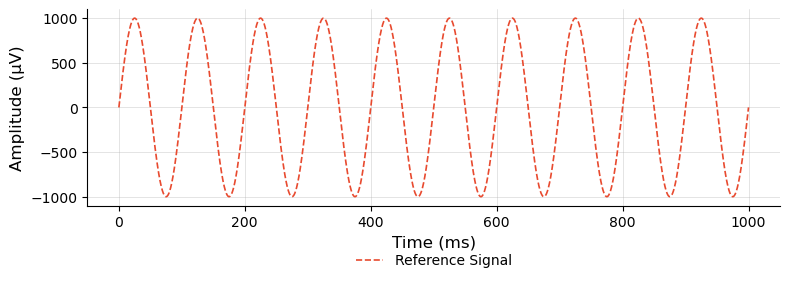

In [66]:
# ── Pure 10 Hz reference sine, 1 s ───────────────────────────────
t_10hz   = np.linspace(0, 1.0, 10_000)  # 1 s, high resolution
sine_10hz = SINE_AMPLITUDE * np.sin(2 * np.pi * 10 * t_10hz)

fig_10, ax_10 = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

ax_10.plot(
    t_10hz * 1000,
    sine_10hz,
    color=SINE_COLOR,
    linewidth=SINE_LINE_WIDTH,
    linestyle=SINE_LINE_STYLE,
    label="Reference Signal"
)

ax_10.set_xlabel("Time (ms)", fontsize=FONT_SIZE_LABEL)
ax_10.set_ylabel("Amplitude (µV)", fontsize=FONT_SIZE_LABEL)
ax_10.tick_params(labelsize=FONT_SIZE_TICK)

if Y_MIN is not None or Y_MAX is not None:
    ax_10.set_ylim(Y_MIN, Y_MAX)

if SHOW_TITLE:
    ax_10.set_title("Pure reference sine — 10 Hz, 1 s", fontsize=FONT_SIZE_TITLE)

ax_10.legend(
    fontsize=LEGEND_FONT_SIZE,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=LEGEND_NCOL,
    frameon=False
)

if SHOW_GRID:
    ax_10.grid(True, linewidth=0.4, alpha=0.6)

ax_10.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

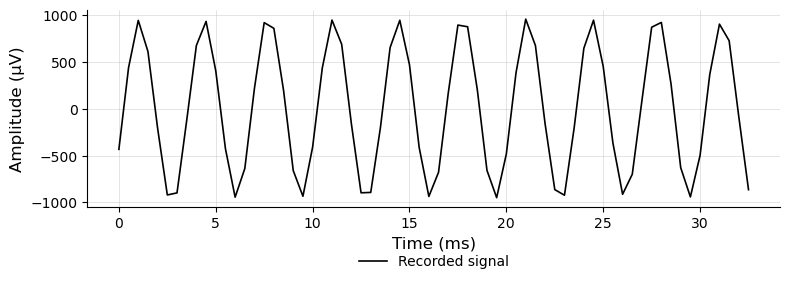

In [67]:
# ── Plot ONLY recorded signal ──────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

ax3.plot(
    time_ms_zeroed,
    signal,
    color=SIGNAL_COLOR_OVERLAY,
    linewidth=SIGNAL_LINE_WIDTH_OVERLAY,
    label="Recorded signal"
)

ax3.set_xlabel("Time (ms)", fontsize=FONT_SIZE_LABEL)
ax3.set_ylabel("Amplitude (µV)", fontsize=FONT_SIZE_LABEL)
ax3.tick_params(labelsize=FONT_SIZE_TICK)

if Y_MIN is not None or Y_MAX is not None:
    ax3.set_ylim(Y_MIN, Y_MAX)

if SHOW_TITLE:
    ax3.set_title(
        f"{CHANNEL} — recorded signal",
        fontsize=FONT_SIZE_TITLE
    )

ax3.legend(
    fontsize=LEGEND_FONT_SIZE,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    frameon=False
)

if SHOW_GRID:
    ax3.grid(True, linewidth=0.4, alpha=0.6)

ax3.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [68]:
# ── Amplitude fit style ────────────────────────────────────────────
SINE_COLOR_FITTED      = "#2F7BE8"   # color of the amplitude-fitted sine
SINE_LINE_STYLE_FITTED = "--"
SINE_LINE_WIDTH_FITTED = 1.2

# inherits all other style params from Cell 5 and Cell 7

Fitted amplitude:    964.76 ± 6.66 µV  (input: 1000 µV)
Fitted phase offset: -28.11 ± 0.39°
Amplitude error:     35.24 µV  (3.52%)


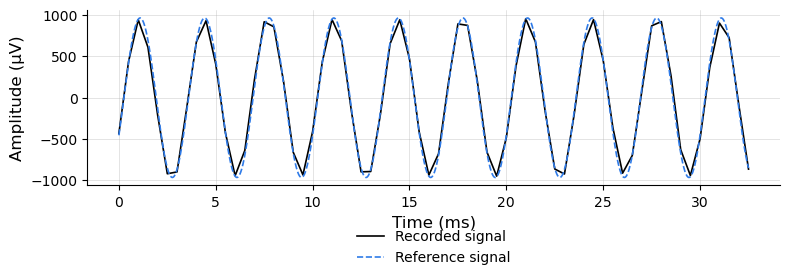

In [69]:
from scipy.optimize import curve_fit

# ── Model: A * sin(2π f t + φ) ─────────────────────────────────────
def sine_model(t, amplitude, phase):
    return amplitude * np.sin(2 * np.pi * F_INPUT * t + phase)

# ── Initial guess: use cross-correlation phase from Cell 8 ─────────
p0 = [SINE_AMPLITUDE, phase_offset]

popt, pcov = curve_fit(sine_model, t_local, signal, p0=p0)
perr       = np.sqrt(np.diag(pcov))

A_fit   = popt[0]
phi_fit = popt[1]
A_err   = perr[0]
phi_err = perr[1]

print(f"Fitted amplitude:    {A_fit:.2f} ± {A_err:.2f} µV  (input: {SINE_AMPLITUDE} µV)")
print(f"Fitted phase offset: {np.degrees(phi_fit):.2f} ± {np.degrees(phi_err):.2f}°")
print(f"Amplitude error:     {abs(A_fit - SINE_AMPLITUDE):.2f} µV  "
      f"({abs(A_fit - SINE_AMPLITUDE) / SINE_AMPLITUDE * 100:.2f}%)")

# ── Build fitted sine on high-res grid ────────────────────────────
fitted_sine_ls = sine_model(t_hires, A_fit, phi_fit)

# ── Plot ───────────────────────────────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

ax4.plot(time_ms_zeroed, signal,
         color=SIGNAL_COLOR_OVERLAY,
         linewidth=SIGNAL_LINE_WIDTH_OVERLAY,
         label="Recorded signal")

ax4.plot(t_hires * 1000, fitted_sine_ls,
         color=SINE_COLOR_FITTED,
         linewidth=SINE_LINE_WIDTH_FITTED,
         linestyle=SINE_LINE_STYLE_FITTED,
         label="Reference signal")

ax4.set_xlabel("Time (ms)", fontsize=FONT_SIZE_LABEL)
ax4.set_ylabel("Amplitude (µV)", fontsize=FONT_SIZE_LABEL)
ax4.tick_params(labelsize=FONT_SIZE_TICK)

if Y_MIN is not None or Y_MAX is not None:
    ax4.set_ylim(Y_MIN, Y_MAX)

if SHOW_TITLE:
    ax4.set_title(f"{CHANNEL} — fitted amplitude: {A_fit:.0f} µV, "
                  f"φ = {np.degrees(phi_fit):.1f}°",
                  fontsize=FONT_SIZE_TITLE)

ax4.legend(fontsize=LEGEND_FONT_SIZE,
           loc="upper center",
           bbox_to_anchor=(0.5, -0.18),
           ncol=LEGEND_NCOL,
           frameon=False)

if SHOW_GRID:
    ax4.grid(True, linewidth=0.4, alpha=0.6)

ax4.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## Plotting - 8 channels à 4 kHz

In [70]:
df = pd.read_csv("data/300Hz_input_8_ch_4kHz_sampling_2kHz_fH_04.csv", sep=None, engine="python")

In [71]:
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Detected separator — inferred from above")
df.head()

Shape: (170716, 9)
Columns: ['sample_num', 'ch0', 'ch7', 'ch10', 'ch11', 'ch12', 'ch13', 'ch14', 'ch15']
Detected separator — inferred from above


,sample_num,ch0,ch7,ch10,ch11,ch12,ch13,ch14,ch15
0,0,-7.0,385.0,-6336.0,-5662.0,-6189.0,-6389.0,-5086.0,-6389.0
1,1,-1.0,-538.0,-6361.0,-5591.0,-6095.0,-6389.0,-4994.0,-6389.0
2,2,-3.0,-818.0,-6284.0,-5544.0,-6047.0,-6389.0,-4952.0,-6389.0
3,3,-3.0,-1313.0,-6249.0,-5499.0,-5977.0,-6389.0,-4897.0,-6389.0
4,4,0.0,-1741.0,-6158.0,-5428.0,-5917.0,-6389.0,-4846.0,-6389.0


In [72]:
FS = 4000  # Hz, sampling rate

n_samples = len(df)
duration_ms = n_samples / FS * 1000

print(f"Samples:  {n_samples}")
print(f"Duration: {duration_ms:.1f} ms")

max_duration_ms = duration_ms  # used as upper bound in plotting cell

Samples:  170716
Duration: 42679.0 ms


In [73]:
# ── Signal parameters ──────────────────────────────────────────────
FS          = 4000
F_INPUT     = 300    # Hz, input signal frequency
CHANNEL     = "ch7"  # which channel to plot

# ── Window ─────────────────────────────────────────────────────────
START_MS    = 16000      # ms, start of the plot window

N_CYCLES    = 10      # number of oscillations to show (takes priority if not None)
WINDOW_MS   = None   # ms, time window to show (used if N_CYCLES is None)

# ── Axis limits ────────────────────────────────────────────────────
Y_MIN       = None   # µV, set to None for auto
Y_MAX       = None   # µV, set to None for auto

# ── Figure style ───────────────────────────────────────────────────
FIG_WIDTH   = 8      # inches
FIG_HEIGHT  = 3      # inches
LINE_WIDTH  = 1.2    # pt
LINE_COLOR  = "black"

FONT_SIZE_LABEL  = 12  # axis label font size
FONT_SIZE_TICK   = 10  # tick label font size
FONT_SIZE_TITLE  = 13  # title font size

SHOW_GRID   = True
SHOW_TITLE  = None

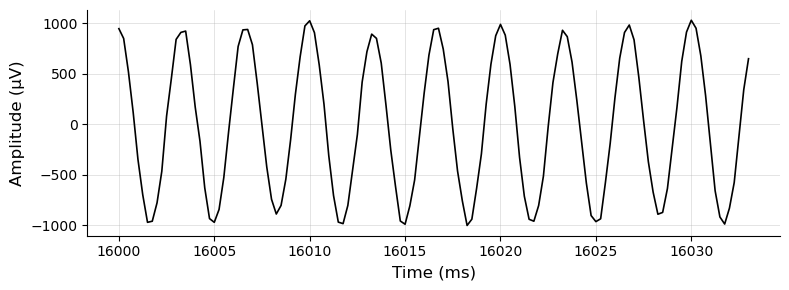

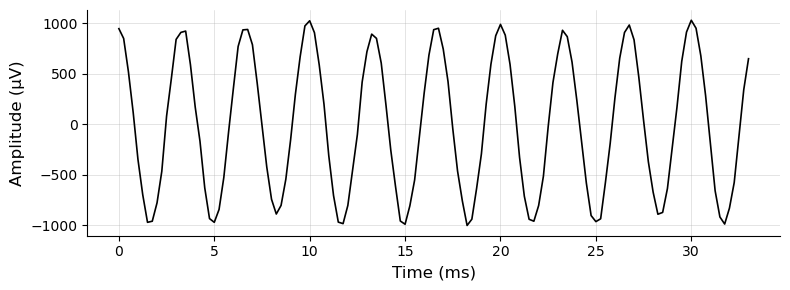

In [74]:
# ── Derived quantities ─────────────────────────────────────────────
if N_CYCLES is not None:
    window_ms = N_CYCLES / F_INPUT * 1000
else:
    window_ms = WINDOW_MS

end_ms = START_MS + window_ms
assert end_ms <= max_duration_ms, (
    f"Window end ({end_ms:.1f} ms) exceeds recording length ({max_duration_ms:.1f} ms)"
)

# ── Slice data ─────────────────────────────────────────────────────
start_idx = int(START_MS / 1000 * FS)
end_idx   = int(end_ms   / 1000 * FS)

time_ms = np.arange(start_idx, end_idx) / FS * 1000  # ms
signal  = df[CHANNEL].iloc[start_idx:end_idx].values  # µV

# ── Plot ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

ax.plot(time_ms, signal, linewidth=LINE_WIDTH, color=LINE_COLOR)

ax.set_xlabel("Time (ms)", fontsize=FONT_SIZE_LABEL)
ax.set_ylabel("Amplitude (µV)", fontsize=FONT_SIZE_LABEL)
ax.tick_params(labelsize=FONT_SIZE_TICK)

if Y_MIN is not None or Y_MAX is not None:
    ax.set_ylim(Y_MIN, Y_MAX)

if SHOW_TITLE:
    title = (f"{CHANNEL} — {F_INPUT} Hz input, "
             f"f_s = {FS} Hz, "
             f"{N_CYCLES} cycles" if N_CYCLES else f"{window_ms:.1f} ms window")
    ax.set_title(title, fontsize=FONT_SIZE_TITLE)

if SHOW_GRID:
    ax.grid(True, linewidth=0.4, alpha=0.6)

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# ── Same plot with x-axis starting at 0 ───────────────────────────
time_ms_zeroed = time_ms - time_ms[0]

fig2, ax2 = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

ax2.plot(time_ms_zeroed, signal, linewidth=LINE_WIDTH, color=LINE_COLOR)

ax2.set_xlabel("Time (ms)", fontsize=FONT_SIZE_LABEL)
ax2.set_ylabel("Amplitude (µV)", fontsize=FONT_SIZE_LABEL)
ax2.tick_params(labelsize=FONT_SIZE_TICK)

if Y_MIN is not None or Y_MAX is not None:
    ax2.set_ylim(Y_MIN, Y_MAX)

if SHOW_TITLE:
    ax2.set_title(title, fontsize=FONT_SIZE_TITLE)

if SHOW_GRID:
    ax2.grid(True, linewidth=0.4, alpha=0.6)

ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [75]:
# ── Sine fit style ─────────────────────────────────────────────────
SINE_COLOR      = "#E84A2F"   # color of the reference sine
SINE_LINE_STYLE = "--"        # linestyle for reference sine
SINE_LINE_WIDTH = 1.2         # pt
SINE_AMPLITUDE  = 1000        # µV, known input amplitude

SIGNAL_COLOR_OVERLAY = "black"
SIGNAL_LINE_WIDTH_OVERLAY = 1.2

LEGEND_FONT_SIZE = 10
LEGEND_LOCATION  = "upper right"  # "upper right", "lower right", etc.

SINE_OVERSAMPLE = 100  # factor above FS for the reference sine (higher = smoother curve)

# inherits FIG_WIDTH, FIG_HEIGHT, FONT_SIZE_LABEL, FONT_SIZE_TICK,
# FONT_SIZE_TITLE, SHOW_GRID, Y_MIN, Y_MAX from Cell 5

Target FFT bin: 10  (300.75 Hz)
Phase offset:   90.54°


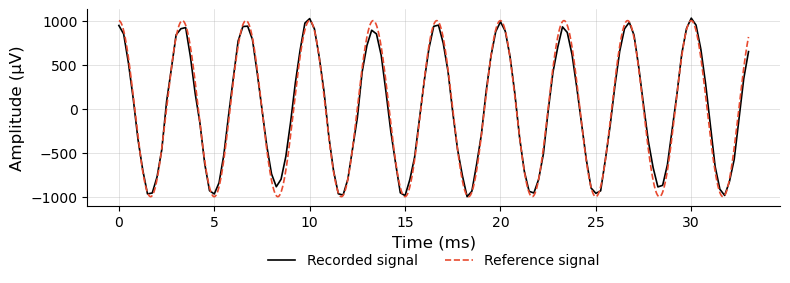

In [76]:
LEGEND_NCOL = 2   # number of columns in the legend

# ── Build reference sine on signal grid ───────────────────────────
n_samples_window = len(signal)
t_local = np.arange(n_samples_window) / FS
t_hires = np.linspace(0, t_local[-1],
                      n_samples_window * SINE_OVERSAMPLE)

ref_sine = np.sin(2 * np.pi * F_INPUT * t_local)

# ── FFT-based phase estimation (exact, no sample quantization) ─────
freq_resolution = FS / n_samples_window
target_bin      = round(F_INPUT / freq_resolution)

S = np.fft.rfft(signal - signal.mean())
R = np.fft.rfft(ref_sine)

phase_offset = np.angle(S[target_bin]) - np.angle(R[target_bin])

# ── Build fitted sine on high-res grid ────────────────────────────
fitted_sine = SINE_AMPLITUDE * np.sin(2 * np.pi * F_INPUT * t_hires + phase_offset)

print(f"Target FFT bin: {target_bin}  ({target_bin * freq_resolution:.2f} Hz)")
print(f"Phase offset:   {np.degrees(phase_offset):.2f}°")

# ── Plot ───────────────────────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

ax3.plot(time_ms_zeroed, signal,
         color=SIGNAL_COLOR_OVERLAY,
         linewidth=SIGNAL_LINE_WIDTH_OVERLAY,
         label="Recorded signal")

ax3.plot(t_hires * 1000, fitted_sine,
         color=SINE_COLOR,
         linewidth=SINE_LINE_WIDTH,
         linestyle=SINE_LINE_STYLE,
         label="Reference signal")

ax3.set_xlabel("Time (ms)", fontsize=FONT_SIZE_LABEL)
ax3.set_ylabel("Amplitude (µV)", fontsize=FONT_SIZE_LABEL)
ax3.tick_params(labelsize=FONT_SIZE_TICK)

if Y_MIN is not None or Y_MAX is not None:
    ax3.set_ylim(Y_MIN, Y_MAX)

if SHOW_TITLE:
    ax3.set_title(f"{CHANNEL} vs. reference signal — phase offset {np.degrees(phase_offset):.1f}°",
                  fontsize=FONT_SIZE_TITLE)

ax3.legend(fontsize=LEGEND_FONT_SIZE,
           loc="upper center",
           bbox_to_anchor=(0.5, -0.18),
           ncol=LEGEND_NCOL,
           frameon=False)

if SHOW_GRID:
    ax3.grid(True, linewidth=0.4, alpha=0.6)

ax3.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [77]:
# ── Amplitude fit style ────────────────────────────────────────────
SINE_COLOR_FITTED      = "#2F7BE8"   # color of the amplitude-fitted sine
SINE_LINE_STYLE_FITTED = "--"
SINE_LINE_WIDTH_FITTED = 1.2

# inherits all other style params from Cell 5 and Cell 7

Fitted amplitude:    965.46 ± 7.33 µV  (input: 1000 µV)
Fitted phase offset: 90.63 ± 0.43°
Amplitude error:     34.54 µV  (3.45%)


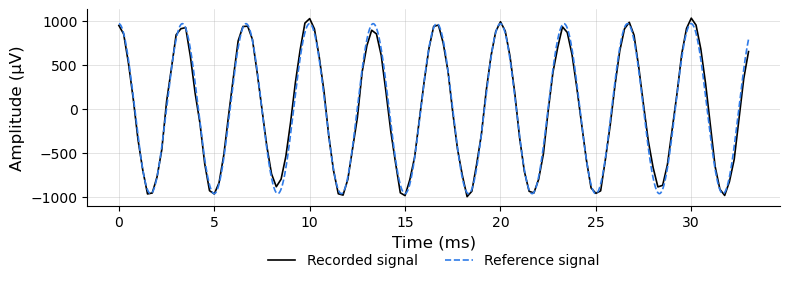

In [78]:
from scipy.optimize import curve_fit

# ── Model: A * sin(2π f t + φ) ─────────────────────────────────────
def sine_model(t, amplitude, phase):
    return amplitude * np.sin(2 * np.pi * F_INPUT * t + phase)

# ── Initial guess: use cross-correlation phase from Cell 8 ─────────
p0 = [SINE_AMPLITUDE, phase_offset]

popt, pcov = curve_fit(sine_model, t_local, signal, p0=p0)
perr       = np.sqrt(np.diag(pcov))

A_fit   = popt[0]
phi_fit = popt[1]
A_err   = perr[0]
phi_err = perr[1]

print(f"Fitted amplitude:    {A_fit:.2f} ± {A_err:.2f} µV  (input: {SINE_AMPLITUDE} µV)")
print(f"Fitted phase offset: {np.degrees(phi_fit):.2f} ± {np.degrees(phi_err):.2f}°")
print(f"Amplitude error:     {abs(A_fit - SINE_AMPLITUDE):.2f} µV  "
      f"({abs(A_fit - SINE_AMPLITUDE) / SINE_AMPLITUDE * 100:.2f}%)")

# ── Build fitted sine on high-res grid ────────────────────────────
fitted_sine_ls = sine_model(t_hires, A_fit, phi_fit)

# ── Plot ───────────────────────────────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

ax4.plot(time_ms_zeroed, signal,
         color=SIGNAL_COLOR_OVERLAY,
         linewidth=SIGNAL_LINE_WIDTH_OVERLAY,
         label="Recorded signal")

ax4.plot(t_hires * 1000, fitted_sine_ls,
         color=SINE_COLOR_FITTED,
         linewidth=SINE_LINE_WIDTH_FITTED,
         linestyle=SINE_LINE_STYLE_FITTED,
         label="Reference signal")

ax4.set_xlabel("Time (ms)", fontsize=FONT_SIZE_LABEL)
ax4.set_ylabel("Amplitude (µV)", fontsize=FONT_SIZE_LABEL)
ax4.tick_params(labelsize=FONT_SIZE_TICK)

if Y_MIN is not None or Y_MAX is not None:
    ax4.set_ylim(Y_MIN, Y_MAX)

if SHOW_TITLE:
    ax4.set_title(f"{CHANNEL} — fitted amplitude: {A_fit:.0f} µV, "
                  f"φ = {np.degrees(phi_fit):.1f}°",
                  fontsize=FONT_SIZE_TITLE)

ax4.legend(fontsize=LEGEND_FONT_SIZE,
           loc="upper center",
           bbox_to_anchor=(0.5, -0.18),
           ncol=LEGEND_NCOL,
           frameon=False)

if SHOW_GRID:
    ax4.grid(True, linewidth=0.4, alpha=0.6)

ax4.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## Flex PCB

### Experimental Setup

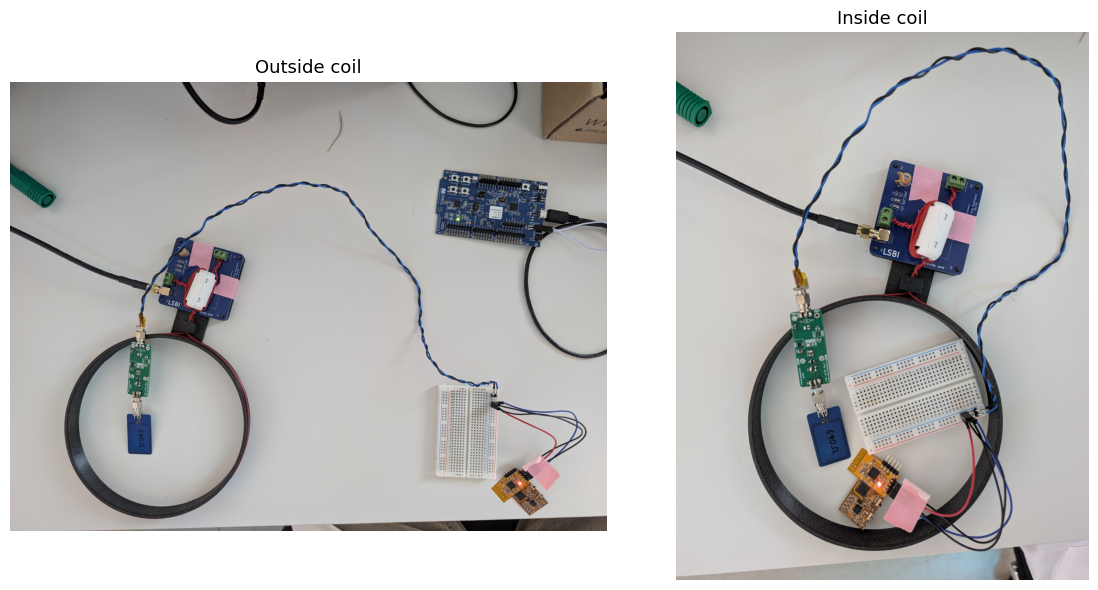

In [79]:
from PIL import Image

IMG_FIG_WIDTH  = 12   # inches
IMG_FIG_HEIGHT = 6    # inches

outside_img = Image.open("data/outside.jpg").rotate(90, expand=True)
inside_img  = Image.open("data/inside.jpg").rotate(90,expand=True)

fig, axes = plt.subplots(1, 2, figsize=(IMG_FIG_WIDTH, IMG_FIG_HEIGHT))

axes[0].imshow(outside_img)
axes[0].set_title("Outside coil", fontsize=FONT_SIZE_TITLE)
axes[0].axis("off")

axes[1].imshow(inside_img)
axes[1].set_title("Inside coil", fontsize=FONT_SIZE_TITLE)
axes[1].axis("off")

plt.tight_layout()
plt.show()

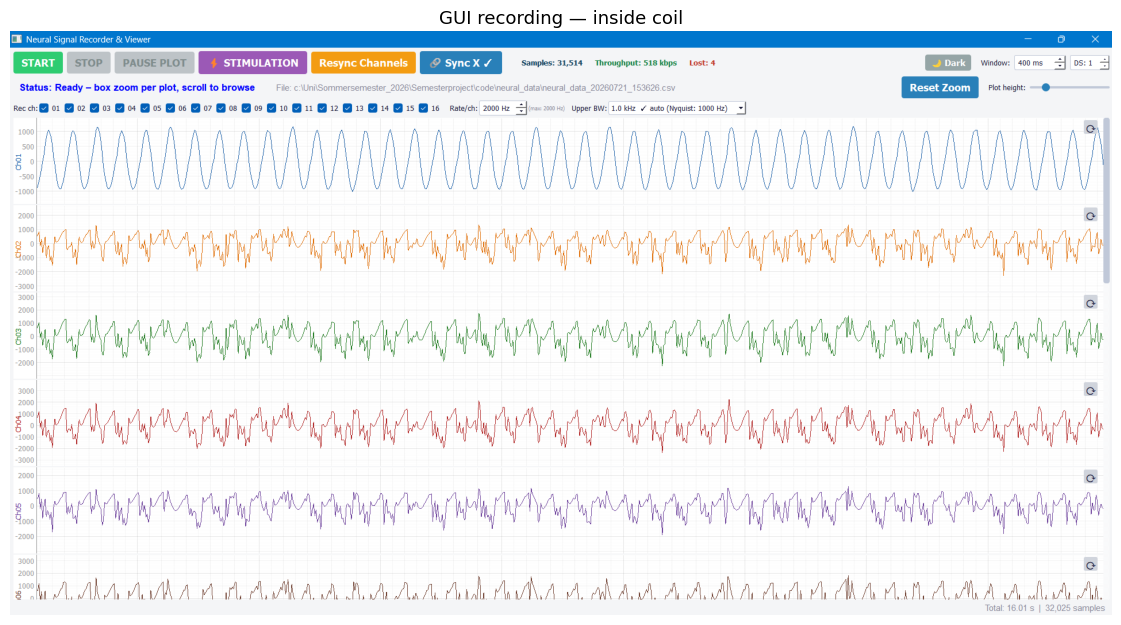

In [80]:
# ── GUI screenshot (inside-coil recording) ────────────────────────
screenshot_img = Image.open("data/flex_pcb_inside.png")
screenshot_ratio = screenshot_img.height / screenshot_img.width

fig, ax = plt.subplots(figsize=(IMG_FIG_WIDTH, IMG_FIG_WIDTH * screenshot_ratio))

ax.imshow(screenshot_img)
ax.set_title("GUI recording — inside coil", fontsize=FONT_SIZE_TITLE)
ax.axis("off")

plt.tight_layout()
plt.show()

### Data Loading — Outside Coil

In [81]:
df = pd.read_csv("data/outside_100Hz_input_16_ch_2kHz_sampling.csv", sep=None, engine="python")

In [82]:
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Detected separator — inferred from above")
df.head()

Shape: (31122, 17)
Columns: ['sample_num', 'ch01', 'ch02', 'ch03', 'ch04', 'ch05', 'ch06', 'ch07', 'ch08', 'ch09', 'ch10', 'ch11', 'ch12', 'ch13', 'ch14', 'ch15', 'ch16']
Detected separator — inferred from above


,sample_num,ch01,ch02,ch03,ch04,ch05,ch06,ch07,ch08,ch09,ch10,ch11,ch12,ch13,ch14,ch15,ch16
0,0,-606.0,-1270.0,-1276.0,-1270.0,-1034.0,-1267.0,-755.0,-883.0,-884.0,-823.0,-366.0,-391.0,-167.0,-123.0,-167.0,123.0
1,1,-804.0,795.0,268.0,-257.0,-55.0,1111.0,-16.0,-83.0,937.0,-365.0,210.0,83.0,97.0,-23.0,55.0,160.0
2,2,-879.0,938.0,-77.0,-674.0,-499.0,400.0,-453.0,-556.0,37.0,-658.0,-101.0,-161.0,-18.0,-51.0,5.0,254.0
3,3,-920.0,1180.0,386.0,-207.0,5.0,1411.0,121.0,39.0,1258.0,-208.0,456.0,344.0,327.0,176.0,323.0,509.0
4,4,-837.0,1447.0,567.0,-163.0,46.0,1730.0,195.0,93.0,1550.0,-103.0,624.0,555.0,494.0,327.0,523.0,804.0


In [83]:
FS = 2000  # Hz, sampling rate

n_samples = len(df)
duration_ms = n_samples / FS * 1000

print(f"Samples:  {n_samples}")
print(f"Duration: {duration_ms:.1f} ms")

max_duration_ms = duration_ms  # used as upper bound in plotting cell

Samples:  31122
Duration: 15561.0 ms


### Plotting — Outside Coil

In [84]:
# ── Signal parameters ──────────────────────────────────────────────
FS          = 2000
F_INPUT     = 100    # Hz, input signal frequency
CHANNEL     = "ch01"  # which channel to plot

# ── Window ─────────────────────────────────────────────────────────
START_MS    = 5300      # ms, start of the plot window

N_CYCLES    = 10      # number of oscillations to show (takes priority if not None)
WINDOW_MS   = None   # ms, time window to show (used if N_CYCLES is None)

# ── Axis limits ────────────────────────────────────────────────────
Y_MIN       = None   # µV, set to None for auto
Y_MAX       = None   # µV, set to None for auto

# ── Figure style ───────────────────────────────────────────────────
FIG_WIDTH   = 8      # inches
FIG_HEIGHT  = 3      # inches
LINE_WIDTH  = 1.2    # pt
LINE_COLOR  = "black"

FONT_SIZE_LABEL  = 12  # axis label font size
FONT_SIZE_TICK   = 10  # tick label font size
FONT_SIZE_TITLE  = 13  # title font size

SHOW_GRID   = True
SHOW_TITLE  = None

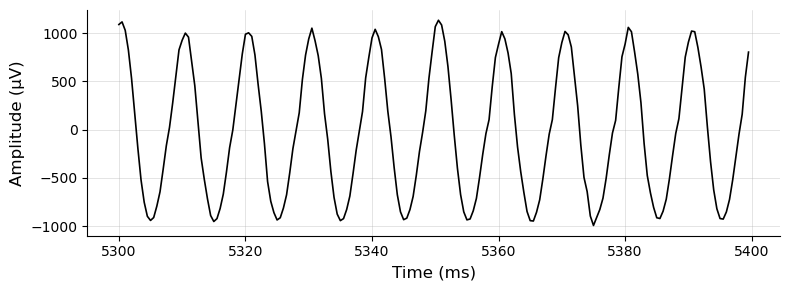

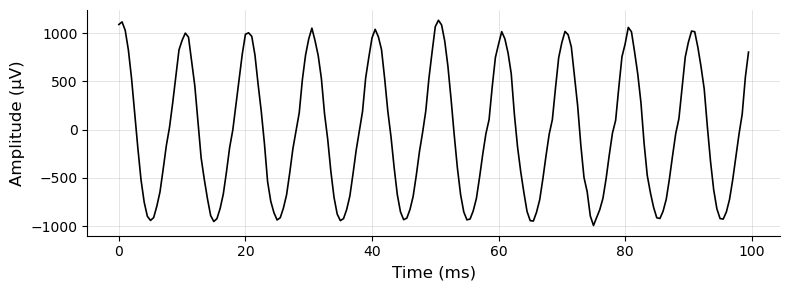

In [85]:
# ── Derived quantities ─────────────────────────────────────────────
if N_CYCLES is not None:
    window_ms = N_CYCLES / F_INPUT * 1000
else:
    window_ms = WINDOW_MS

end_ms = START_MS + window_ms
assert end_ms <= max_duration_ms, (
    f"Window end ({end_ms:.1f} ms) exceeds recording length ({max_duration_ms:.1f} ms)"
)

# ── Slice data ─────────────────────────────────────────────────────
start_idx = int(START_MS / 1000 * FS)
end_idx   = int(end_ms   / 1000 * FS)

time_ms = np.arange(start_idx, end_idx) / FS * 1000  # ms
signal  = df[CHANNEL].iloc[start_idx:end_idx].values  # µV

# ── Plot ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

ax.plot(time_ms, signal, linewidth=LINE_WIDTH, color=LINE_COLOR)

ax.set_xlabel("Time (ms)", fontsize=FONT_SIZE_LABEL)
ax.set_ylabel("Amplitude (µV)", fontsize=FONT_SIZE_LABEL)
ax.tick_params(labelsize=FONT_SIZE_TICK)

if Y_MIN is not None or Y_MAX is not None:
    ax.set_ylim(Y_MIN, Y_MAX)

if SHOW_TITLE:
    title = (f"{CHANNEL} — {F_INPUT} Hz input, "
             f"f_s = {FS} Hz, "
             f"{N_CYCLES} cycles" if N_CYCLES else f"{window_ms:.1f} ms window")
    ax.set_title(title, fontsize=FONT_SIZE_TITLE)

if SHOW_GRID:
    ax.grid(True, linewidth=0.4, alpha=0.6)

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# ── Same plot with x-axis starting at 0 ───────────────────────────
time_ms_zeroed = time_ms - time_ms[0]

fig2, ax2 = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

ax2.plot(time_ms_zeroed, signal, linewidth=LINE_WIDTH, color=LINE_COLOR)

ax2.set_xlabel("Time (ms)", fontsize=FONT_SIZE_LABEL)
ax2.set_ylabel("Amplitude (µV)", fontsize=FONT_SIZE_LABEL)
ax2.tick_params(labelsize=FONT_SIZE_TICK)

if Y_MIN is not None or Y_MAX is not None:
    ax2.set_ylim(Y_MIN, Y_MAX)

if SHOW_TITLE:
    ax2.set_title(title, fontsize=FONT_SIZE_TITLE)

if SHOW_GRID:
    ax2.grid(True, linewidth=0.4, alpha=0.6)

ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [86]:
# ── Sine fit style ─────────────────────────────────────────────────
SINE_COLOR      = "#E84A2F"   # color of the reference sine
SINE_LINE_STYLE = "--"        # linestyle for reference sine
SINE_LINE_WIDTH = 1.2         # pt
SINE_AMPLITUDE  = 1000        # µV, known input amplitude (1 mV)

SIGNAL_COLOR_OVERLAY = "black"
SIGNAL_LINE_WIDTH_OVERLAY = 1.2

LEGEND_FONT_SIZE = 10
LEGEND_LOCATION  = "upper right"  # "upper right", "lower right", etc.

SINE_OVERSAMPLE = 100  # factor above FS for the reference sine (higher = smoother curve)

# inherits FIG_WIDTH, FIG_HEIGHT, FONT_SIZE_LABEL, FONT_SIZE_TICK,
# FONT_SIZE_TITLE, SHOW_GRID, Y_MIN, Y_MAX from Cell 5

Target FFT bin: 10  (100.00 Hz)
Phase offset:   74.87°


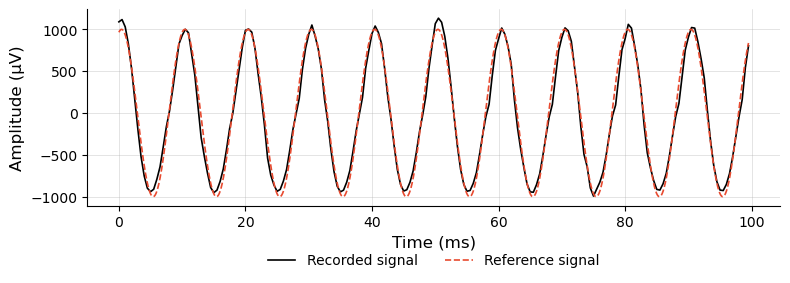

In [87]:
LEGEND_NCOL = 2   # number of columns in the legend

# ── Build reference sine on signal grid ───────────────────────────
n_samples_window = len(signal)
t_local = np.arange(n_samples_window) / FS
t_hires = np.linspace(0, t_local[-1],
                      n_samples_window * SINE_OVERSAMPLE)

ref_sine = np.sin(2 * np.pi * F_INPUT * t_local)

# ── FFT-based phase estimation (exact, no sample quantization) ─────
freq_resolution = FS / n_samples_window
target_bin      = round(F_INPUT / freq_resolution)

S = np.fft.rfft(signal - signal.mean())
R = np.fft.rfft(ref_sine)

phase_offset = np.angle(S[target_bin]) - np.angle(R[target_bin])

# ── Build fitted sine on high-res grid ────────────────────────────
fitted_sine = SINE_AMPLITUDE * np.sin(2 * np.pi * F_INPUT * t_hires + phase_offset)

print(f"Target FFT bin: {target_bin}  ({target_bin * freq_resolution:.2f} Hz)")
print(f"Phase offset:   {np.degrees(phase_offset):.2f}°")

# ── Plot ───────────────────────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

ax3.plot(time_ms_zeroed, signal,
         color=SIGNAL_COLOR_OVERLAY,
         linewidth=SIGNAL_LINE_WIDTH_OVERLAY,
         label="Recorded signal")

ax3.plot(t_hires * 1000, fitted_sine,
         color=SINE_COLOR,
         linewidth=SINE_LINE_WIDTH,
         linestyle=SINE_LINE_STYLE,
         label="Reference signal")

ax3.set_xlabel("Time (ms)", fontsize=FONT_SIZE_LABEL)
ax3.set_ylabel("Amplitude (µV)", fontsize=FONT_SIZE_LABEL)
ax3.tick_params(labelsize=FONT_SIZE_TICK)

if Y_MIN is not None or Y_MAX is not None:
    ax3.set_ylim(Y_MIN, Y_MAX)

if SHOW_TITLE:
    ax3.set_title(f"{CHANNEL} vs. reference signal — phase offset {np.degrees(phase_offset):.1f}°",
                  fontsize=FONT_SIZE_TITLE)

ax3.legend(fontsize=LEGEND_FONT_SIZE,
           loc="upper center",
           bbox_to_anchor=(0.5, -0.18),
           ncol=LEGEND_NCOL,
           frameon=False)

if SHOW_GRID:
    ax3.grid(True, linewidth=0.4, alpha=0.6)

ax3.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

### Data Loading — Inside Coil

In [88]:
df = pd.read_csv("data/inside_100Hz_input_16_ch_2kHz_sampling.csv", sep=None, engine="python")

In [89]:
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Detected separator — inferred from above")
df.head()

Shape: (32025, 17)
Columns: ['sample_num', 'ch01', 'ch02', 'ch03', 'ch04', 'ch05', 'ch06', 'ch07', 'ch08', 'ch09', 'ch10', 'ch11', 'ch12', 'ch13', 'ch14', 'ch15', 'ch16']
Detected separator — inferred from above


,sample_num,ch01,ch02,ch03,ch04,ch05,ch06,ch07,ch08,ch09,ch10,ch11,ch12,ch13,ch14,ch15,ch16
0,0,-62.0,-1125.0,-1221.0,-1864.0,-1197.0,-1039.0,-1064.0,-1274.0,-1193.0,-1390.0,-779.0,-732.0,-572.0,-493.0,-516.0,-359.0
1,1,-390.0,-26.0,-20.0,-601.0,-358.0,80.0,-37.0,-257.0,-180.0,-705.0,-418.0,-231.0,-401.0,-487.0,-403.0,-418.0
2,2,-632.0,-363.0,-437.0,-1137.0,-804.0,-518.0,-606.0,-813.0,-728.0,-1068.0,-587.0,-468.0,-460.0,-441.0,-384.0,-291.0
3,3,-841.0,34.0,53.0,-547.0,-300.0,213.0,87.0,-148.0,73.0,-532.0,-274.0,49.0,-193.0,-304.0,-178.0,-145.0
4,4,-892.0,64.0,119.0,-449.0,-244.0,282.0,192.0,2.0,325.0,-373.0,-120.0,390.0,-7.0,-161.0,63.0,119.0


In [90]:
FS = 2000  # Hz, sampling rate

n_samples = len(df)
duration_ms = n_samples / FS * 1000

print(f"Samples:  {n_samples}")
print(f"Duration: {duration_ms:.1f} ms")

max_duration_ms = duration_ms  # used as upper bound in plotting cell

Samples:  32025
Duration: 16012.5 ms


### Plotting — Inside Coil

In [91]:
# ── Signal parameters ──────────────────────────────────────────────
FS          = 2000
F_INPUT     = 100    # Hz, input signal frequency
CHANNEL     = "ch01"  # which channel to plot

# ── Window ─────────────────────────────────────────────────────────
START_MS    = 5300      # ms, start of the plot window

N_CYCLES    = 10      # number of oscillations to show (takes priority if not None)
WINDOW_MS   = None   # ms, time window to show (used if N_CYCLES is None)

# ── Axis limits ────────────────────────────────────────────────────
Y_MIN       = None   # µV, set to None for auto
Y_MAX       = None   # µV, set to None for auto

# ── Figure style ───────────────────────────────────────────────────
FIG_WIDTH   = 8      # inches
FIG_HEIGHT  = 3      # inches
LINE_WIDTH  = 1.2    # pt
LINE_COLOR  = "black"

FONT_SIZE_LABEL  = 12  # axis label font size
FONT_SIZE_TICK   = 10  # tick label font size
FONT_SIZE_TITLE  = 13  # title font size

SHOW_GRID   = True
SHOW_TITLE  = None

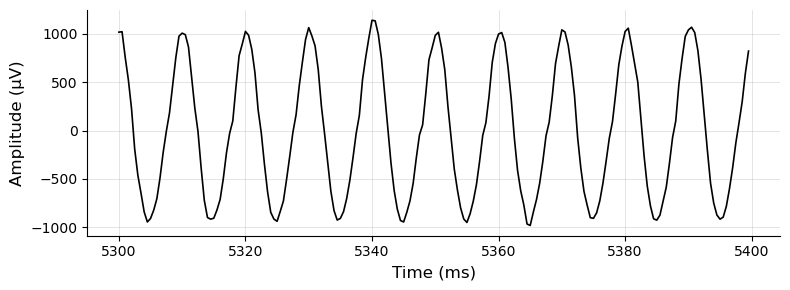

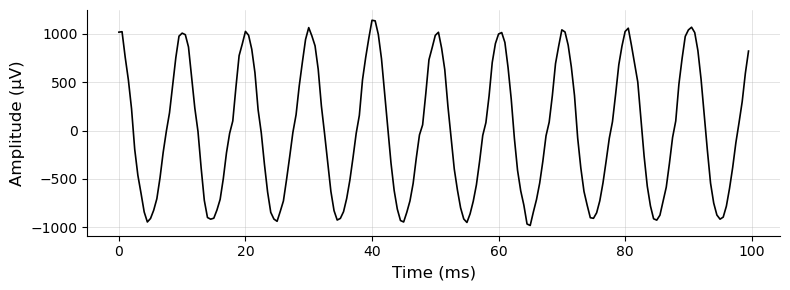

In [92]:
# ── Derived quantities ─────────────────────────────────────────────
if N_CYCLES is not None:
    window_ms = N_CYCLES / F_INPUT * 1000
else:
    window_ms = WINDOW_MS

end_ms = START_MS + window_ms
assert end_ms <= max_duration_ms, (
    f"Window end ({end_ms:.1f} ms) exceeds recording length ({max_duration_ms:.1f} ms)"
)

# ── Slice data ─────────────────────────────────────────────────────
start_idx = int(START_MS / 1000 * FS)
end_idx   = int(end_ms   / 1000 * FS)

time_ms = np.arange(start_idx, end_idx) / FS * 1000  # ms
signal  = df[CHANNEL].iloc[start_idx:end_idx].values  # µV

# ── Plot ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

ax.plot(time_ms, signal, linewidth=LINE_WIDTH, color=LINE_COLOR)

ax.set_xlabel("Time (ms)", fontsize=FONT_SIZE_LABEL)
ax.set_ylabel("Amplitude (µV)", fontsize=FONT_SIZE_LABEL)
ax.tick_params(labelsize=FONT_SIZE_TICK)

if Y_MIN is not None or Y_MAX is not None:
    ax.set_ylim(Y_MIN, Y_MAX)

if SHOW_TITLE:
    title = (f"{CHANNEL} — {F_INPUT} Hz input, "
             f"f_s = {FS} Hz, "
             f"{N_CYCLES} cycles" if N_CYCLES else f"{window_ms:.1f} ms window")
    ax.set_title(title, fontsize=FONT_SIZE_TITLE)

if SHOW_GRID:
    ax.grid(True, linewidth=0.4, alpha=0.6)

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# ── Same plot with x-axis starting at 0 ───────────────────────────
time_ms_zeroed = time_ms - time_ms[0]

fig2, ax2 = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

ax2.plot(time_ms_zeroed, signal, linewidth=LINE_WIDTH, color=LINE_COLOR)

ax2.set_xlabel("Time (ms)", fontsize=FONT_SIZE_LABEL)
ax2.set_ylabel("Amplitude (µV)", fontsize=FONT_SIZE_LABEL)
ax2.tick_params(labelsize=FONT_SIZE_TICK)

if Y_MIN is not None or Y_MAX is not None:
    ax2.set_ylim(Y_MIN, Y_MAX)

if SHOW_TITLE:
    ax2.set_title(title, fontsize=FONT_SIZE_TITLE)

if SHOW_GRID:
    ax2.grid(True, linewidth=0.4, alpha=0.6)

ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [93]:
# ── Sine fit style ─────────────────────────────────────────────────
SINE_COLOR      = "#E84A2F"   # color of the reference sine
SINE_LINE_STYLE = "--"        # linestyle for reference sine
SINE_LINE_WIDTH = 1.2         # pt
SINE_AMPLITUDE  = 1000        # µV, known input amplitude (1 mV)

SIGNAL_COLOR_OVERLAY = "black"
SIGNAL_LINE_WIDTH_OVERLAY = 1.2

LEGEND_FONT_SIZE = 10
LEGEND_LOCATION  = "upper right"  # "upper right", "lower right", etc.

SINE_OVERSAMPLE = 100  # factor above FS for the reference sine (higher = smoother curve)

# inherits FIG_WIDTH, FIG_HEIGHT, FONT_SIZE_LABEL, FONT_SIZE_TICK,
# FONT_SIZE_TITLE, SHOW_GRID, Y_MIN, Y_MAX from Cell 5

Target FFT bin: 10  (100.00 Hz)
Phase offset:   87.76°


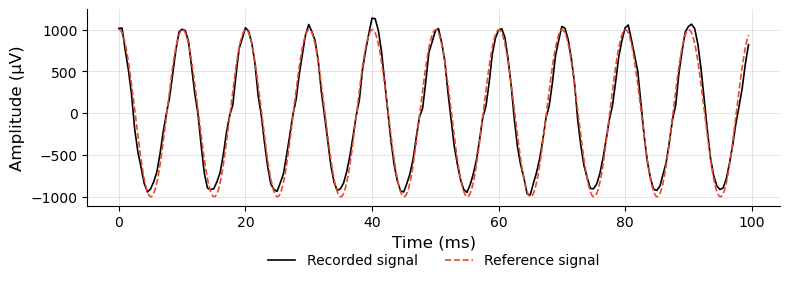

In [94]:
LEGEND_NCOL = 2   # number of columns in the legend

# ── Build reference sine on signal grid ───────────────────────────
n_samples_window = len(signal)
t_local = np.arange(n_samples_window) / FS
t_hires = np.linspace(0, t_local[-1],
                      n_samples_window * SINE_OVERSAMPLE)

ref_sine = np.sin(2 * np.pi * F_INPUT * t_local)

# ── FFT-based phase estimation (exact, no sample quantization) ─────
freq_resolution = FS / n_samples_window
target_bin      = round(F_INPUT / freq_resolution)

S = np.fft.rfft(signal - signal.mean())
R = np.fft.rfft(ref_sine)

phase_offset = np.angle(S[target_bin]) - np.angle(R[target_bin])

# ── Build fitted sine on high-res grid ────────────────────────────
fitted_sine = SINE_AMPLITUDE * np.sin(2 * np.pi * F_INPUT * t_hires + phase_offset)

print(f"Target FFT bin: {target_bin}  ({target_bin * freq_resolution:.2f} Hz)")
print(f"Phase offset:   {np.degrees(phase_offset):.2f}°")

# ── Plot ───────────────────────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

ax3.plot(time_ms_zeroed, signal,
         color=SIGNAL_COLOR_OVERLAY,
         linewidth=SIGNAL_LINE_WIDTH_OVERLAY,
         label="Recorded signal")

ax3.plot(t_hires * 1000, fitted_sine,
         color=SINE_COLOR,
         linewidth=SINE_LINE_WIDTH,
         linestyle=SINE_LINE_STYLE,
         label="Reference signal")

ax3.set_xlabel("Time (ms)", fontsize=FONT_SIZE_LABEL)
ax3.set_ylabel("Amplitude (µV)", fontsize=FONT_SIZE_LABEL)
ax3.tick_params(labelsize=FONT_SIZE_TICK)

if Y_MIN is not None or Y_MAX is not None:
    ax3.set_ylim(Y_MIN, Y_MAX)

if SHOW_TITLE:
    ax3.set_title(f"{CHANNEL} vs. reference signal — phase offset {np.degrees(phase_offset):.1f}°",
                  fontsize=FONT_SIZE_TITLE)

ax3.legend(fontsize=LEGEND_FONT_SIZE,
           loc="upper center",
           bbox_to_anchor=(0.5, -0.18),
           ncol=LEGEND_NCOL,
           frameon=False)

if SHOW_GRID:
    ax3.grid(True, linewidth=0.4, alpha=0.6)

ax3.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()